<center><h1> Three-Eloop </h1></center>

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from MCA_lib import *
import pennylane as qml

## Variables Input

In [4]:
# Número de símbolos que deseas crear
num_ext_edges=3
num_int_edges=3
num_edges =num_ext_edges+num_int_edges


num_no_reverse_clauses = 7

num_propagator_edge = 2

needs_extra_qubit = False

name_diagram = 'Mercedes_opt2'

num_shots = 1000000

cut = 300

## Logical Variables

In [5]:
# Lista para almacenar los símbolos con subíndices
S = make_edges(num_edges)
Sp = make_prime_edges(S)

Set_edges = make_set_edges(S,Sp)

# Ancilla qubits

c = [symbols('c_{}'.format(i)) for i in range(0, num_no_reverse_clauses)]

## Llenado de Ancilla qubits y creación de resultados

In [6]:
# Definir auxiliares
c[0] =  And(S[0],S[1], S[2])

c[1] = And(S[0],S[4], Sp[3])

c[2] = And(S[1], S[5], Sp[4]) #7

c[3] = And(S[2], S[3], Sp[5]) #8
c[4] = And(S[0], S[1], S[5], Sp[3])

c[5] = And(S[1], S[2], S[3], Sp[4]) #9


c[6] = And(S[0], S[2], S[4], Sp[5])




######################## Total ######################

clauses = [*c, *reverse_clauses(c, S, Sp)]

## Matriz de adyacencia - Clausulas

In [7]:
Graph_matrix_clauses = adjacent_matrix_clauses(clauses, Set_edges)
print(Graph_matrix_clauses)

[[0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 1. 1. 0. 1.]
 [0. 1. 1. 0. 1. 0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 0. 1. 1. 1. 0. 1.]
 [0. 1. 0. 0. 1. 0. 1. 1. 1. 1.]
 [0. 0. 1. 0. 1. 1. 0. 0. 1. 1.]
 [1. 0. 1. 0. 1. 1. 0. 0. 1. 0.]
 [1. 0. 0. 1. 0. 1. 1. 1. 0. 0.]
 [1. 0. 1. 1. 1. 1. 1. 0. 0. 0.]]


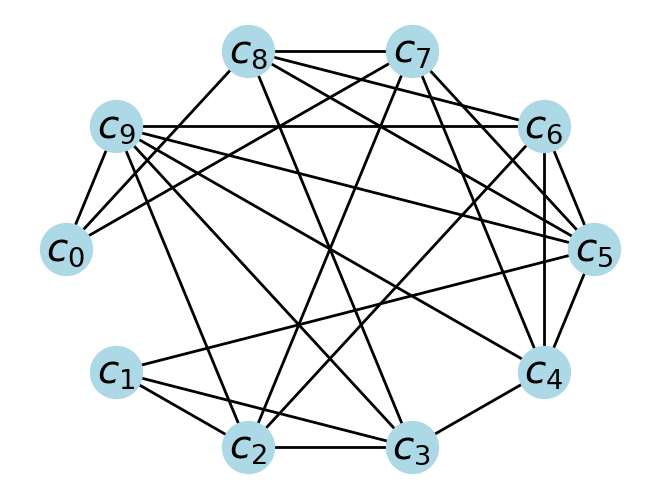

In [8]:
graph_clauses = graph_clauses(clauses, Set_edges, draw = True, name_graph = 'xmen_clauses')

[2, 3, 5]


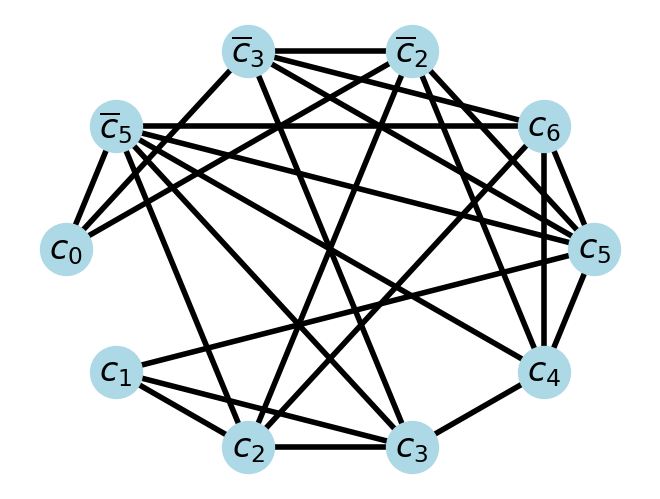

In [9]:
graph_clausesR = graph_clauses_Rev(S,c,clauses, Set_edges, draw = True, name_graph = '3e12prov2_clauses')

## Manual Creation of the MEC graph

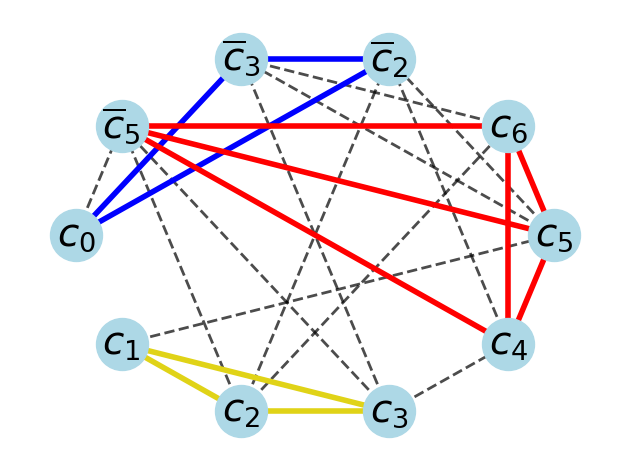

In [10]:
G = nx.Graph()
G.add_node("$c_0$")
G.add_node("$c_1$")
G.add_node("$c_2$")
G.add_node("$c_3$")
G.add_node("$c_4$")
G.add_node("$c_5$")
G.add_node("$c_6$")
G.add_node("$\overline{{c}}_2$")
G.add_node("$\overline{{c}}_3$")
G.add_node("$\overline{{c}}_5$")
G.add_edge("$c_0$", "$\overline{{c}}_5$", weight=0.5)
G.add_edge("$c_0$", "$\overline{{c}}_2$", weight=1)
G.add_edge("$c_0$", "$\overline{{c}}_3$", weight=1)

G.add_edge("$\overline{{c}}_2$", "$\overline{{c}}_3$", weight=1)
G.add_edge("$\overline{{c}}_2$", "$c_2$", weight=0.5)
G.add_edge("$\overline{{c}}_2$", "$c_4$", weight=0.5)
G.add_edge("$\overline{{c}}_2$", "$c_5$", weight=0.5)

G.add_edge("$\overline{{c}}_5$", "$c_2$", weight=0.5)
G.add_edge("$\overline{{c}}_5$", "$c_3$", weight=0.5)
G.add_edge("$\overline{{c}}_5$", "$c_4$", weight=3)
G.add_edge("$\overline{{c}}_5$", "$c_5$", weight=3)
G.add_edge("$\overline{{c}}_5$", "$c_6$", weight=3)
G.add_edge("$\overline{{c}}_3$", "$c_3$", weight=0.5)
G.add_edge("$\overline{{c}}_3$", "$c_5$", weight=0.5)
G.add_edge("$\overline{{c}}_3$", "$c_6$", weight=0.5)

G.add_edge("$c_1$", "$c_2$", weight=2)
G.add_edge("$c_1$", "$c_3$", weight=2)
G.add_edge("$c_1$", "$c_5$", weight=0.5)
G.add_edge("$c_2$", "$c_3$", weight=2)
G.add_edge("$c_2$", "$c_6$", weight=0.5)
G.add_edge("$c_3$", "$c_4$", weight=0.5)
G.add_edge("$c_4$", "$c_5$", weight=3)
G.add_edge("$c_4$", "$c_6$", weight=3)
G.add_edge("$c_5$", "$c_6$", weight=3)





e1 = [(u, v) for (u, v, d) in G.edges(data=True) if 0.5< d["weight"]   <=1]
e2 = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] ==2]
e3 = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] == 3]
esmall = [(u, v) for (u, v, d) in G.edges(data=True) if  d["weight"] <= 0.5]

pos = nx.shell_layout(G)  # positions for all nodes - seed for reproducibility

# nodes
nx.draw_networkx_nodes(G, pos, node_size=1400, node_color='lightblue')

# edges
nx.draw_networkx_edges(G, pos, edgelist=esmall,alpha=0.7 ,width=2, style="dashed")
nx.draw_networkx_edges(
    G, pos, edgelist=e1, width=4, alpha=1, edge_color="b", style="solid"
)
nx.draw_networkx_edges(
    G, pos, edgelist=e2, width=4, alpha=1, edge_color="#E0D317", style="solid"
)
nx.draw_networkx_edges(
    G, pos, edgelist=e3, width=4, alpha=1, edge_color="r", style="solid"
)

# node labels
nx.draw_networkx_labels(G, pos, font_size=28, font_family="sans-serif")
# edge weight labels


ax = plt.gca()
ax.margins(0.08)
ax.set_facecolor("red")
ax.axis("off")

#plt.figure(facecolor="none")
plt.tight_layout()
plt.savefig('3e12clauses.pdf',format="pdf",dpi=300,bbox_inches='tight',pad_inches=0.05)
plt.show()


In [11]:
clauses_combination = Graph_condition_combination(graph_clauses)
clauses_combination

[[5, 4, 9, 6], [0, 8, 7], [1, 2, 3]]

## Depth

In [12]:
total_args = sum(len(clause.args) for clause in clauses)
intersec_expression = And(*clauses)
#print(clauses)
print(intersec_expression)
num_elements_intersec_expr = len(intersec_expression.args)

#print((num_elements_intersec_expr < total_args) and not_subexpressions(intersec_expression, Set_edges))

not_subexpressions(intersec_expression, Set_edges)


S^'_1 & S^'_2 & S^'_3 & S^'_4 & S^'_5 & S_0 & S_1 & S_2 & S_3 & S_4 & S_5


False

In [13]:
Graph_matrix_depth = adjacent_matrix_depth(clauses, Set_edges)
print(Graph_matrix_depth)

[[0. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1. 1. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0. 0. 1. 0. 0. 1.]
 [0. 1. 1. 0. 1. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 1. 1. 0.]]


## Manual Creation of the MCC graph

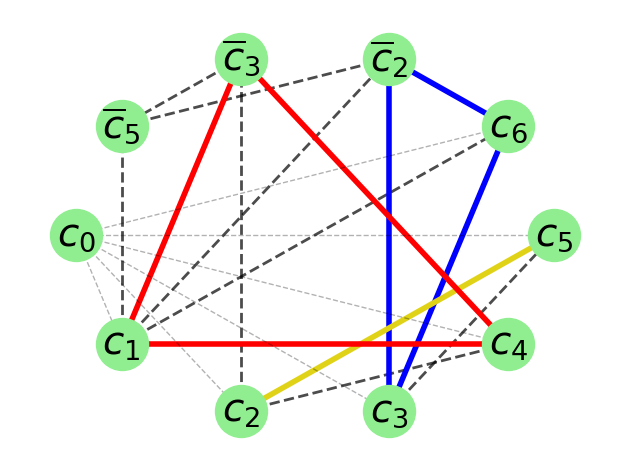

In [14]:
G = nx.Graph()
G.add_node("$c_0$")
G.add_node("$c_1$")
G.add_node("$c_2$")
G.add_node("$c_3$")
G.add_node("$c_4$")
G.add_node("$c_5$")
G.add_node("$c_6$")
G.add_node("$\overline{{c}}_2$")
G.add_node("$\overline{{c}}_3$")
G.add_node("$\overline{{c}}_5$")


G.add_edge("$c_0$", "$c_1$", weight=0)
G.add_edge("$c_0$", "$c_2$", weight=0)
G.add_edge("$c_0$", "$c_3$", weight=0)
G.add_edge("$c_0$", "$c_4$", weight=0)
G.add_edge("$c_0$", "$c_5$", weight=0)
G.add_edge("$c_0$", "$c_6$", weight=0)


G.add_edge("$\overline{{c}}_2$", "$c_1$", weight=0.5)
G.add_edge("$\overline{{c}}_2$", "$c_3$", weight=1)
G.add_edge("$\overline{{c}}_2$", "$c_6$", weight=1)

G.add_edge("$\overline{{c}}_5$", "$c_1$", weight=0.5)
G.add_edge("$\overline{{c}}_5$", "$\overline{{c}}_3$", weight=0.5)
G.add_edge("$\overline{{c}}_5$", "$\overline{{c}}_2$", weight=0.5)


G.add_edge("$\overline{{c}}_3$", "$c_1$", weight=3)
G.add_edge("$\overline{{c}}_3$", "$c_2$", weight=0.5)
G.add_edge("$\overline{{c}}_3$", "$c_4$", weight=3)

G.add_edge("$c_1$", "$c_4$", weight=3)
G.add_edge("$c_1$", "$c_6$", weight=0.5)
G.add_edge("$c_2$", "$c_5$", weight=2)
G.add_edge("$c_2$", "$c_4$", weight=0.5)
G.add_edge("$c_3$", "$c_5$", weight=0.5)
G.add_edge("$c_3$", "$c_6$", weight=1)







e1 = [(u, v) for (u, v, d) in G.edges(data=True) if 0.5< d["weight"]   <=1]
e2 = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] ==2]
e3 = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] == 3]
esmall = [(u, v) for (u, v, d) in G.edges(data=True) if  0< d["weight"] <= 0.5]
enull=[(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] ==0]

pos = nx.shell_layout(G)  # positions for all nodes - seed for reproducibility

# nodes
nx.draw_networkx_nodes(G, pos, node_size=1400, node_color='lightgreen')

# edges
nx.draw_networkx_edges(G, pos, edgelist=esmall,alpha=0.7 ,width=2, style="dashed")
nx.draw_networkx_edges(
    G, pos, edgelist=e1, width=4, alpha=1, edge_color="b", style="solid"
)
nx.draw_networkx_edges(
    G, pos, edgelist=e2, width=4, alpha=1, edge_color="#E0D317", style="solid"
)
nx.draw_networkx_edges(
    G, pos, edgelist=e3, width=4, alpha=1, edge_color="r", style="solid"
)
nx.draw_networkx_edges(
    G, pos, edgelist=enull, width=1, alpha=0.3, style="dashed"
)
# node labels
nx.draw_networkx_labels(G, pos, font_size=28, font_family="sans-serif")
# edge weight labels


ax = plt.gca()
ax.margins(0.08)
#plt.figure(facecolor="none")
#plt.axis("off")
ax.set_facecolor("white")
ax.axis("off")


plt.tight_layout()
plt.savefig('3e12depth.pdf',format="pdf",dpi=300,bbox_inches='tight',pad_inches=0.05)
plt.show()

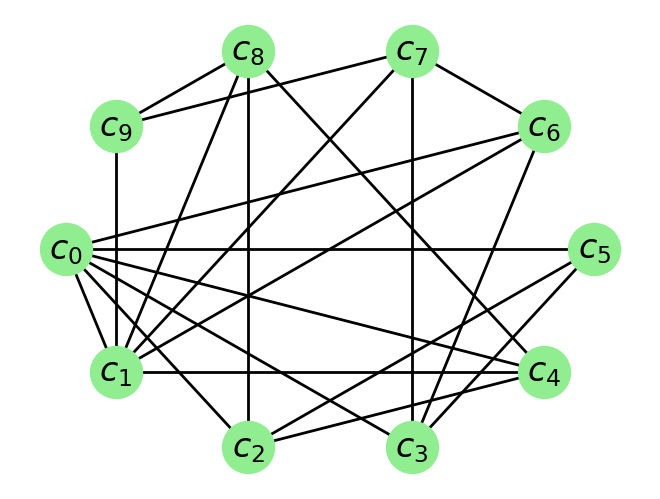

In [15]:
graph_depth = graph_depth(clauses, Set_edges, draw = True, name_graph = 'xmen_depht')

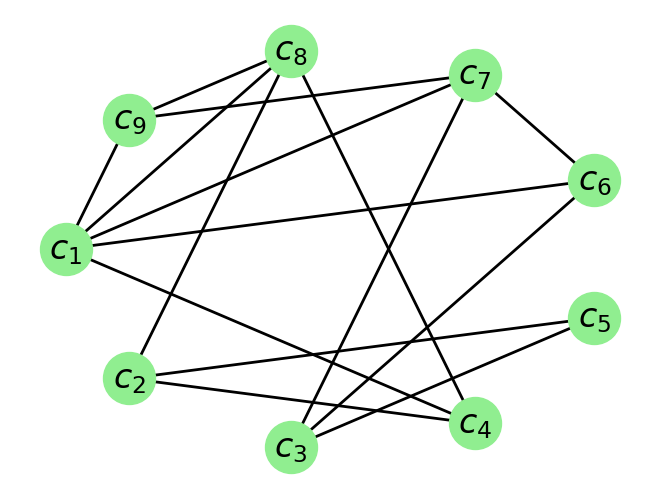

In [16]:
graph_depth3 = graph_depth3(clauses,num_ext_edges ,Set_edges, draw = True)

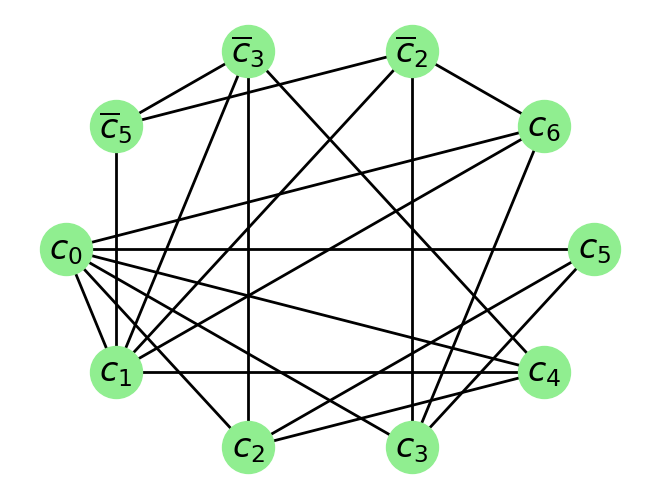

In [17]:
graph_depth7 = graph_depth7(S,c,clauses,num_ext_edges ,Set_edges, draw = True)

In [18]:
depth_combination = Graph_condition_combination(graph_depth)
depth_combination


[[0, 1, 4], [3, 6, 7], [8, 9], [2, 5]]

In [19]:
depth_combination3 = Graph_condition_combination3(graph_depth3,clauses, num_ext_edges)
depth_combination3


[[0, 3, 7], [2, 5, 6], [1, 4], [8]]


[[0], [1, 4, 8], [3, 6, 7], [2, 5], [9]]

<left><h2> Qubits </h2></left>

In [20]:
# Numbers of qubits to use
num_auxs = len(clauses_combination)

# Qubits
edges_to_propag, e = edges_to_propagators(S, num_propagator_edge = num_propagator_edge)
clauses_to_aux,a = clauses_auxiliar(clauses, clauses_combination)

mark = 'out'


# Wires

total_wires = [*e, *a, mark]
init_states_wires = e

multi_controll_wires = [e[0], *a, mark]

if needs_extra_qubit:
    extra = 'extra'
    total_wires.insert(0, extra)
    init_states_wires.insert(0, extra)
    multi_controll_wires.insert(0, extra)

# Circuit

In [21]:
dev = qml.device('default.qubit', wires = total_wires, shots = num_shots)
qml.templates.GroverOperator.__name__ = "Diffusion Operator"

def circuit_function(depth_combination3):
    @qml.transforms.cancel_inverses
    @qml.qnode(dev)
    def circuit():
        #State preparation
        qml.broadcast(qml.Hadamard, init_states_wires, 'single')
        qml.broadcast(qml.PauliX, a, 'single')
        qml.PauliX(wires = mark)
        qml.Hadamard(wires = mark)
        # Oracle
        oracle(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        #
        qml.MultiControlledX(wires = multi_controll_wires)
        # Adjoint Oracle
        qml.simplify(qml.adjoint(oracle))(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        # Grover Diffuser
        qml.templates.GroverOperator(wires=init_states_wires)
        return qml.counts(wires = init_states_wires)
    return circuit

In [22]:
circuit3 = circuit_function([[1, 8, 9], [3, 6, 7], [2, 4], [0], [5]])

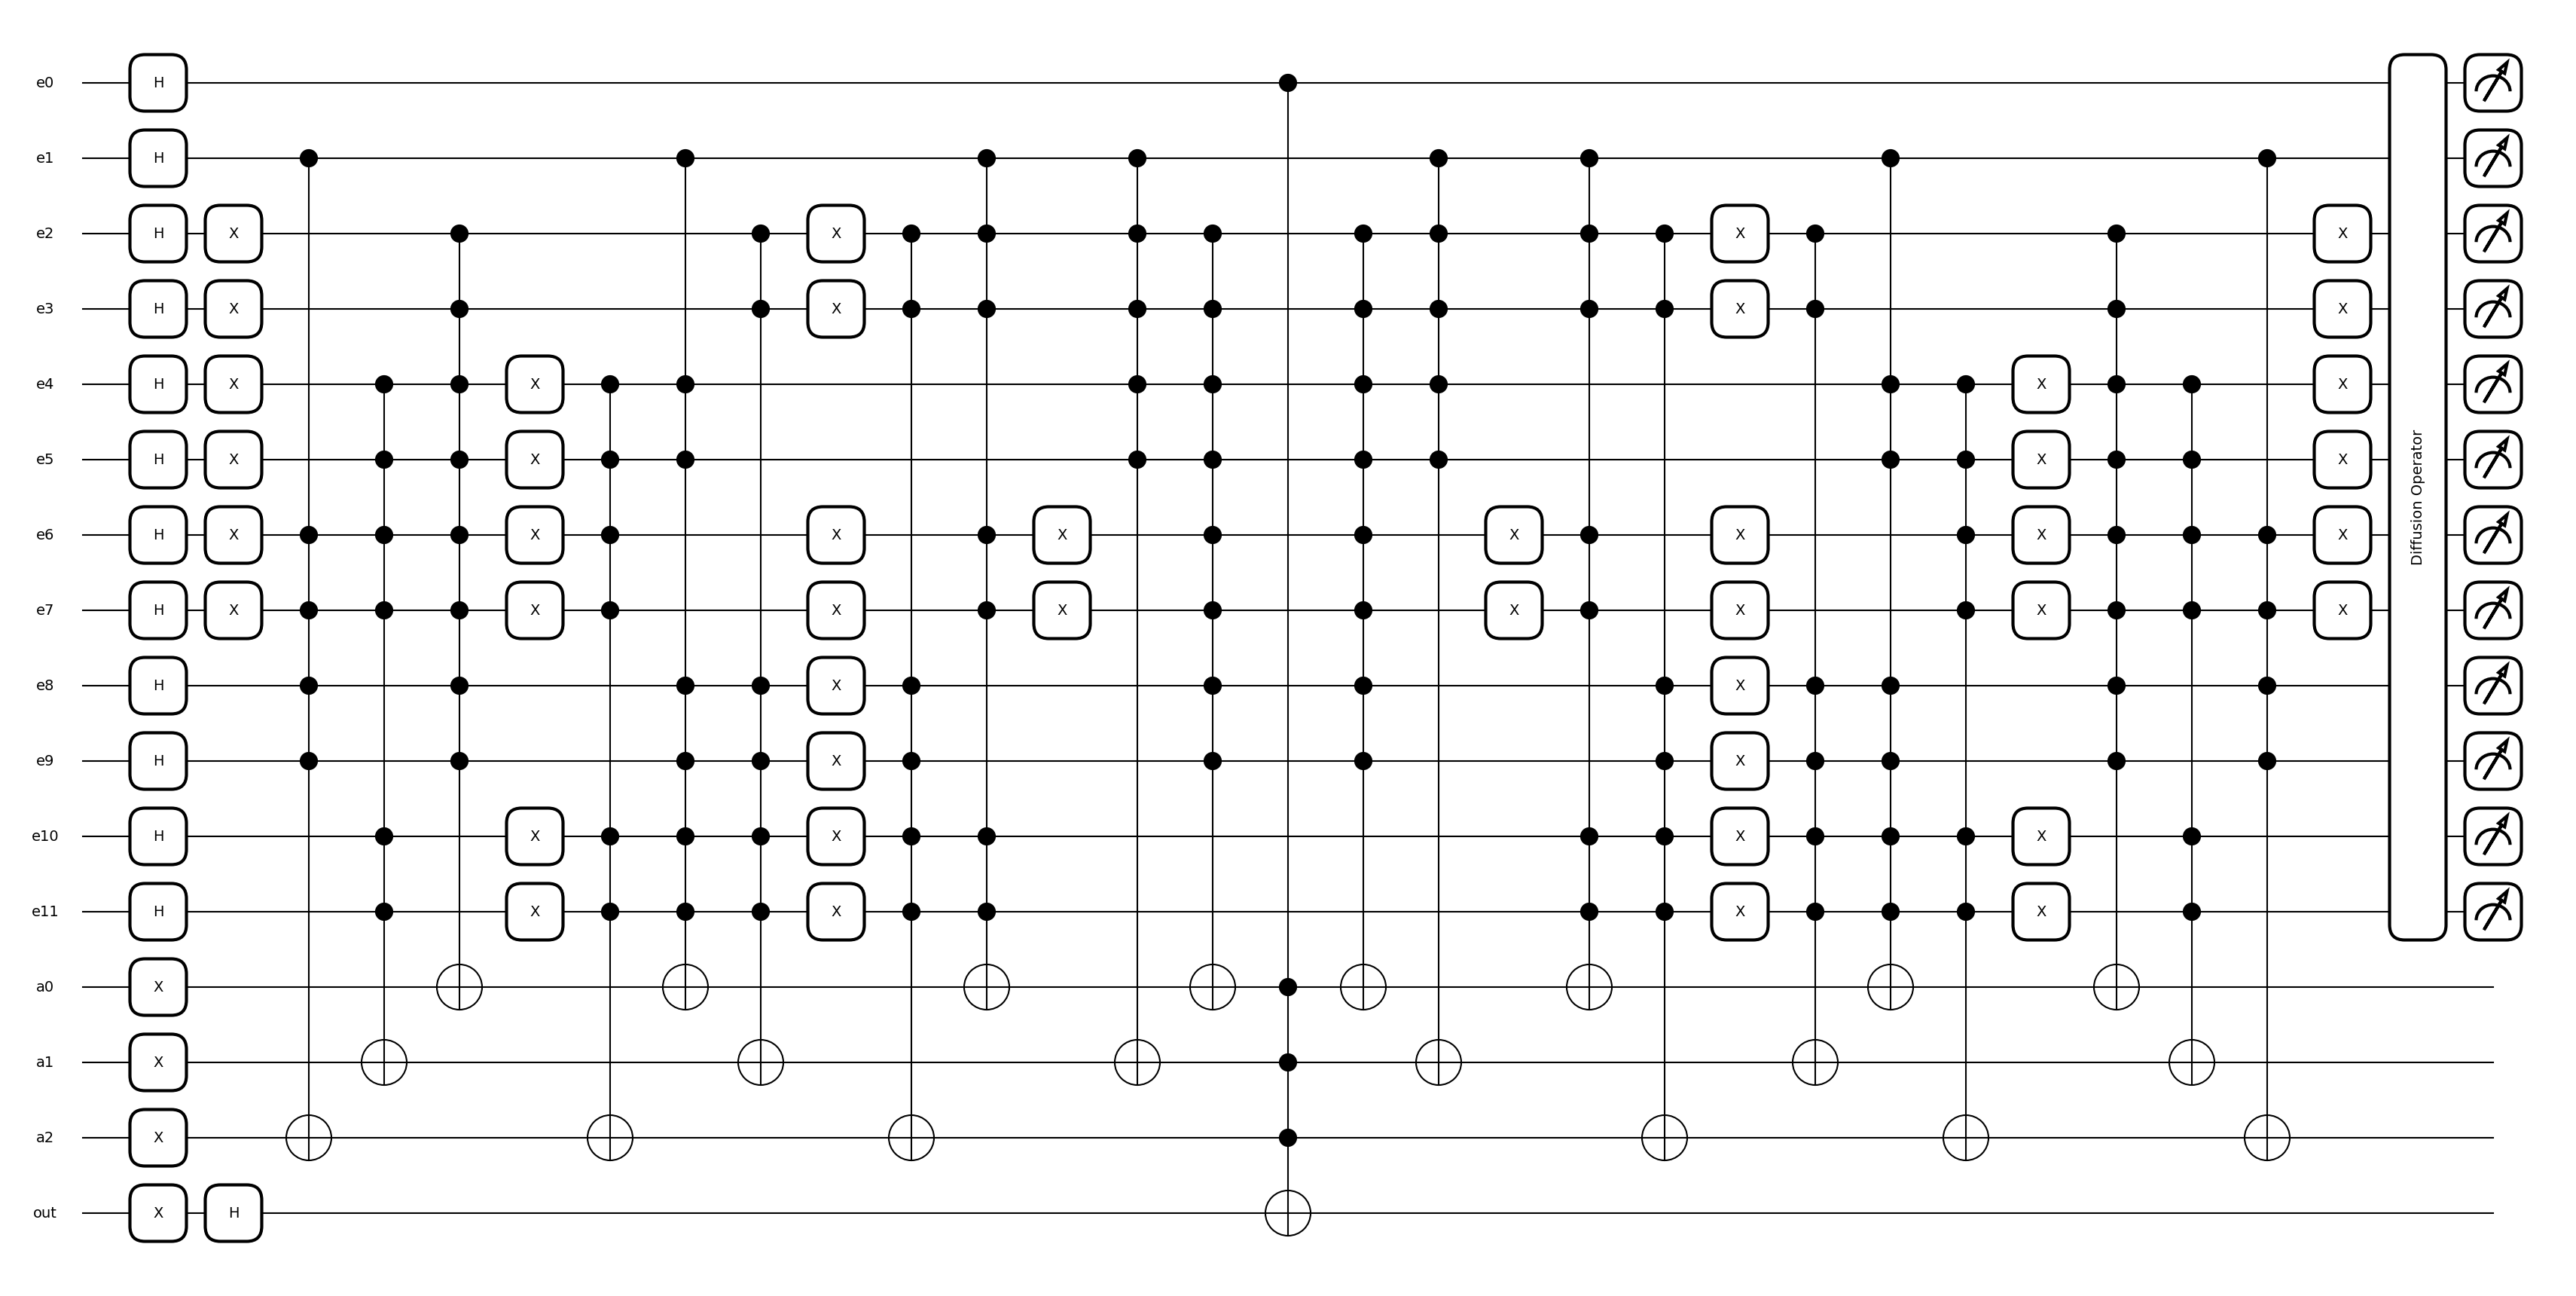

In [23]:
Draw_circuit(circuit3, wire_order_list= total_wires, name_file = name_diagram)

In [24]:
plt.rcParams['patch.facecolor'] = 'w'
plt.rcParams['patch.edgecolor'] = 'black'
plt.rcParams['text.color'] = 'blue'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['patch.linewidth'] = 6
plt.rcParams['patch.force_edgecolor'] = True
plt.rcParams['lines.color'] = 'black'
plt.rcParams['lines.linewidth'] = 6
plt.rcParams['figure.facecolor'] = 'w'
plt.rcParams['axes.labelsize']=24


To generate te same appearance as the paper we need to use the function Draw_circuit2

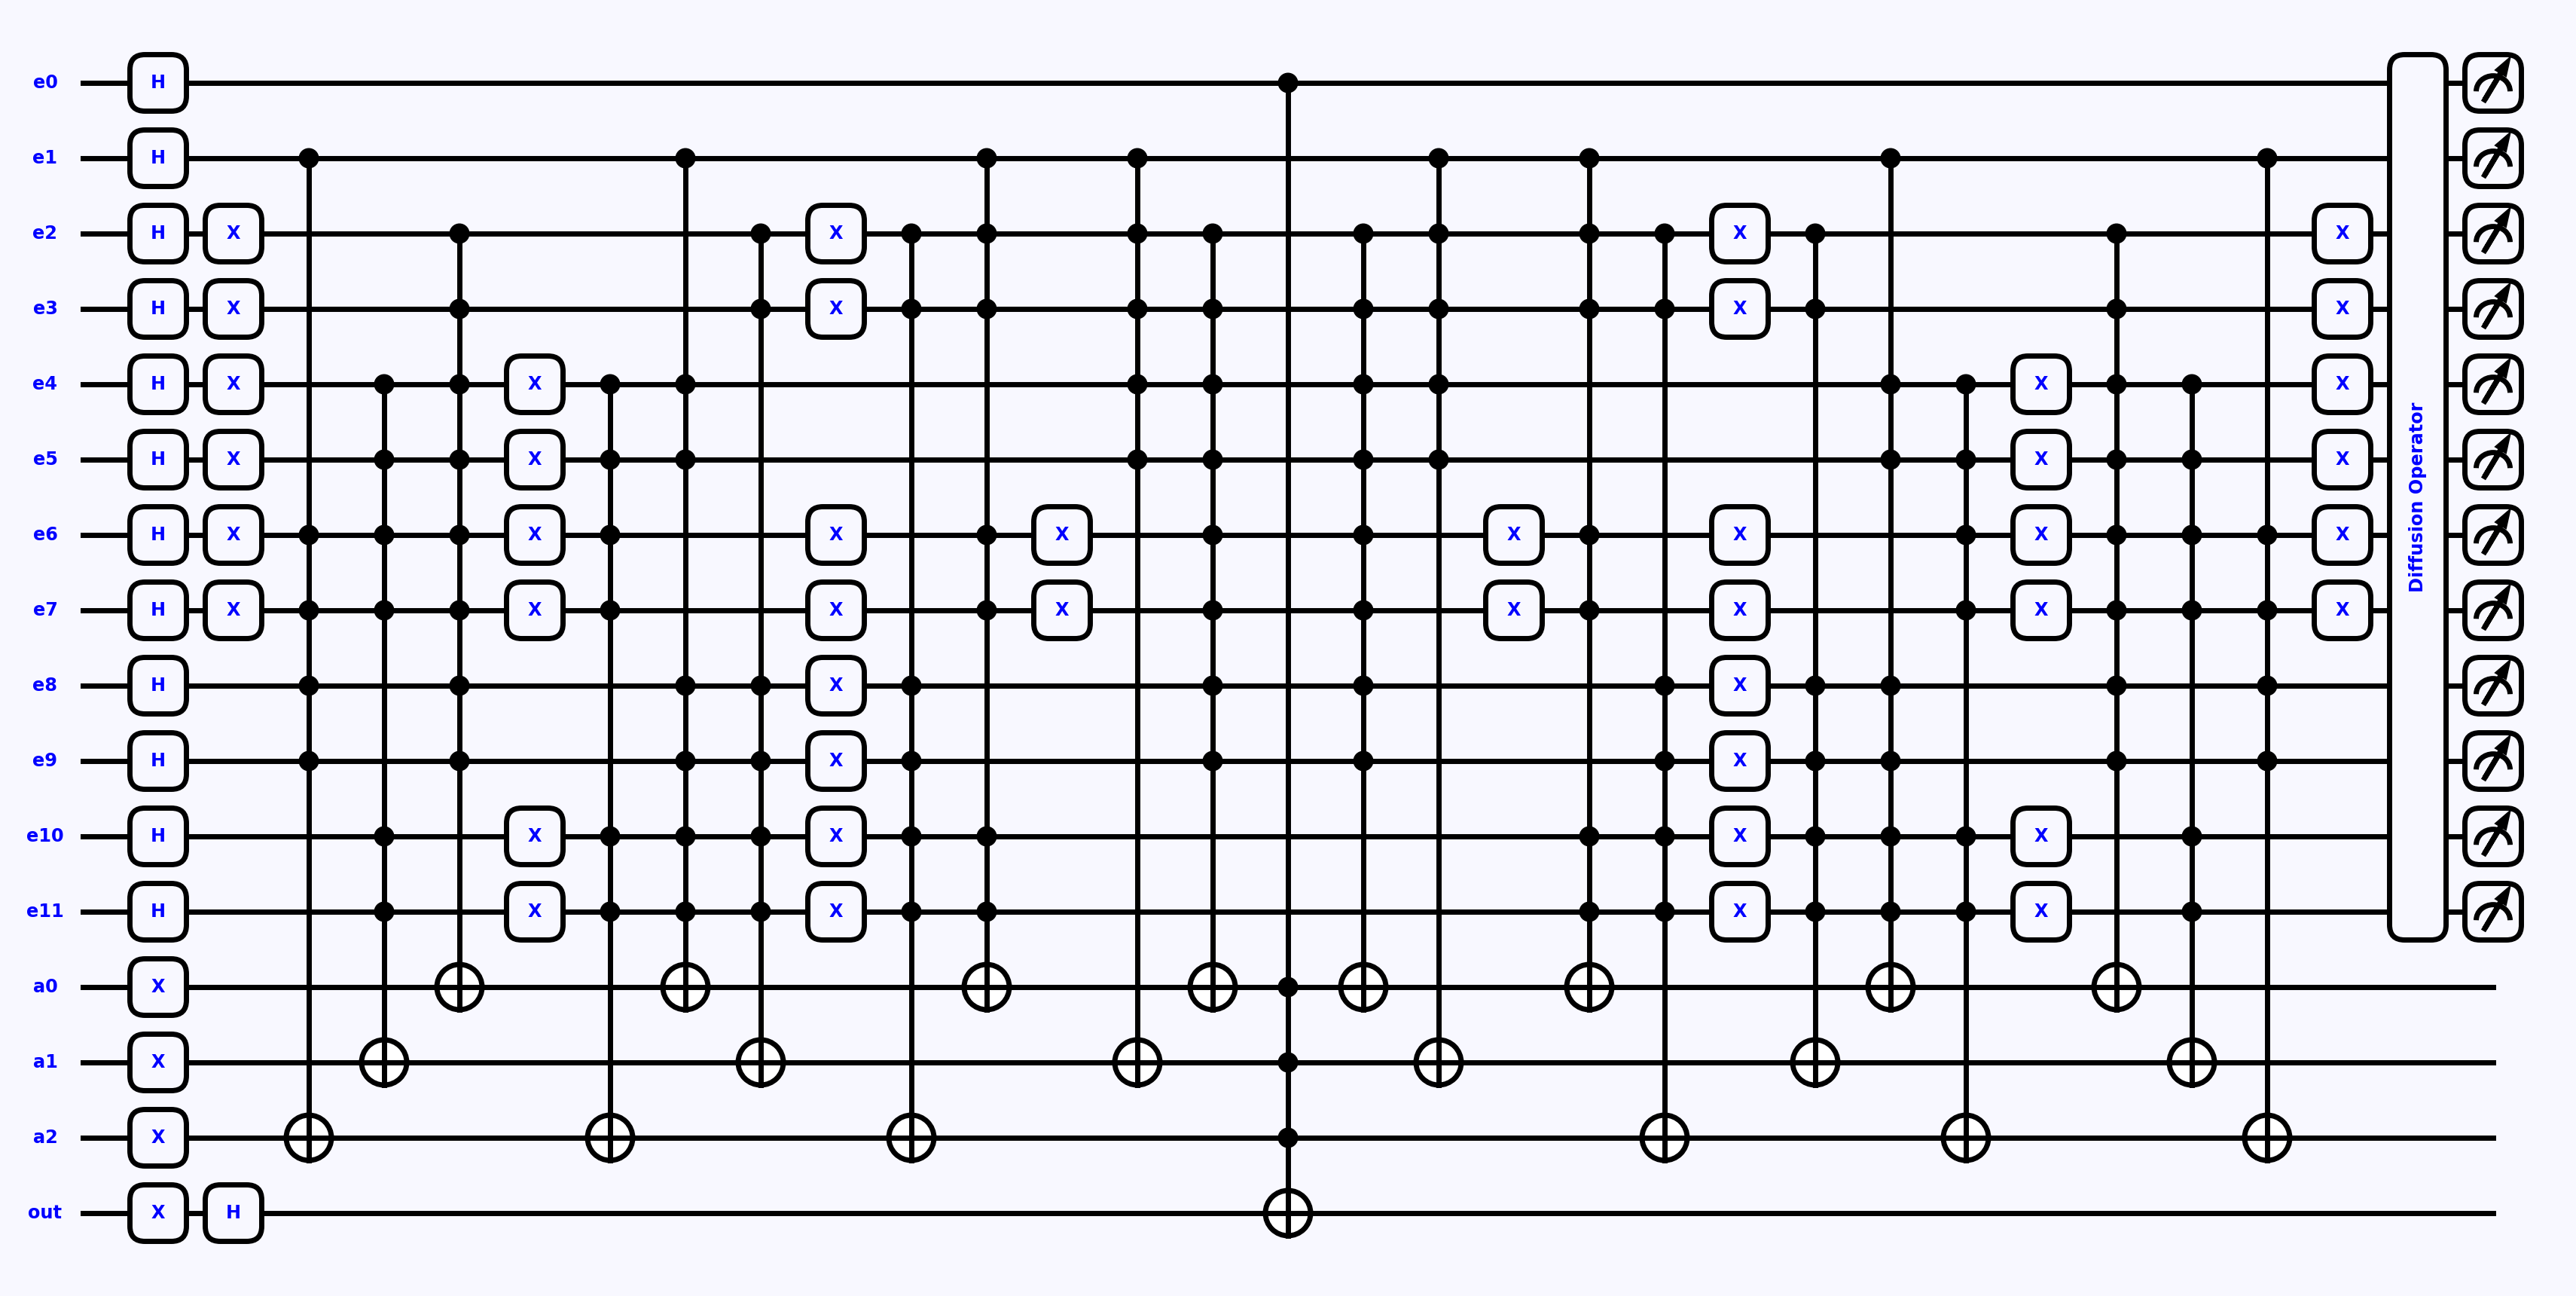

In [25]:
Draw_circuit2(circuit3, wire_order_list= total_wires, name_file = name_diagram)

In [26]:
get_depth(circuit3)

The numer of depth of is: 29


In [27]:
num_casual_states(circuit3(), cut = cut)

The number of casual states is: 1804


# Prueba con OPTUNA

In [ ]:
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

import itertools

def generar_todas_combinaciones(subconjuntos):
    # Generar todas las permutaciones internas
    permutaciones_internas = [list(itertools.permutations(sub)) for sub in subconjuntos]

    # Producto cartesiano de las permutaciones internas
    producto_cartesiano = itertools.product(*permutaciones_internas)

    # Generar todas las permutaciones del orden de los subconjuntos
    combinaciones_finales = [
        [list(grupo) for grupo in perm]  # Convertir cada tupla interna a lista
        for combinacion in producto_cartesiano
        for perm in itertools.permutations(combinacion)
    ]

    return combinaciones_finales

# Definir el conjunto
subconjuntos = [[0], [1, 4, 8], [3, 6, 7], [2, 5], [9]]
 # Ejemplo de subconjuntos
combinaciones = generar_todas_combinaciones(subconjuntos)


results = {}
for combinacion in combinaciones: 
    results[f"{combinacion}"] = depth_circuit(combinacion)

mejor_combinacion = min(results, key=results.get)
valor_minimo = results[mejor_combinacion]

print("Mejor combinación:", mejor_combinacion)
print("Valor mínimo:", valor_minimo)

In [ ]:
results

In [ ]:
len(combinaciones)

In [ ]:
import itertools
import optuna
import math

# Lista de subconjuntos base
subconjuntos_base = [[0, 1, 4], [3, 6, 7], [8, 9], [2, 5]]


# Precomputar permutaciones internas de cada subconjunto (como listas de tuplas)
permutaciones_por_subconjunto = [
    list(itertools.permutations(sub)) for sub in subconjuntos_base
]

# Precomputar número de permutaciones por subconjunto
num_permutaciones = [len(p) for p in permutaciones_por_subconjunto]

# Total de combinaciones internas
total_comb_internas = math.prod(num_permutaciones)

# Total de permutaciones de orden de subconjuntos
total_ordenes = math.factorial(len(subconjuntos_base))

# Total de combinaciones posibles (no generamos todas)
espacio_total = total_comb_internas * total_ordenes

# Función ficticia a optimizar (reemplaza esto con tu lógica real)
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

# Decodificar un índice entero único en una combinación (sin generar todas)
def decodificar_combinacion(idx):
    n = len(subconjuntos_base)

    # Obtener el orden de los subconjuntos (perm index → permutación)
    orden_idx = idx % total_ordenes
    comb_idx = idx // total_ordenes

    orden = list(itertools.permutations(range(n)))[orden_idx]

    # Decodificar índices internos para cada subconjunto
    indices_internos = []
    for i in reversed(range(n)):
        p = num_permutaciones[i]
        indices_internos.append(comb_idx % p)
        comb_idx //= p
    indices_internos = list(reversed(indices_internos))

    # Construir la combinación final
    combinacion = [list(permutaciones_por_subconjunto[i][indices_internos[i]]) for i in orden]
    return combinacion

# Función de evaluación para Optuna
def objective(trial):
    idx = trial.suggest_int("idx", 0, espacio_total - 1)
    combinacion = decodificar_combinacion(idx)
    return depth_circuit(combinacion)

# Ejecutar la optimización
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2000)  # puedes ajustar el número de pruebas

# Mostrar el mejor resultado
mejor_idx = study.best_params["idx"]
mejor_combinacion = decodificar_combinacion(mejor_idx)
print("Mejor combinación:", mejor_combinacion)
print("Valor mínimo:", study.best_value)
